# TMDB Movie Data Analysis

#### 1. Setup.

importing modules and enable auto-reload (so edits to the `.py` are picked up without restarting the kernel).

In [17]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# our own modules
import config
import ingestion
import preprocessing
import analysis
import visualization

pd.set_option("display.max_columns", None)

# confirm the API token was loaded from .env
config.check_token()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
TMDB token loaded successfully.


True

#### 2. fetching movie data from the API

In [4]:
# Fetch all movies listed in config.MOVIE_IDS (invalid ids like 0 are skipped)
raw_df = ingestion.fetch_movies()
raw_df.head()

  ! Skipping id 0 (HTTP 404)
  ok  Fetched 'Avengers: Endgame' (id 299534)
  ok  Fetched 'Avatar' (id 19995)
  ok  Fetched 'Star Wars: The Force Awakens' (id 140607)
  ok  Fetched 'Avengers: Infinity War' (id 299536)
  ok  Fetched 'Titanic' (id 597)
  ok  Fetched 'Jurassic World' (id 135397)
  ok  Fetched 'The Lion King' (id 420818)
  ok  Fetched 'The Avengers' (id 24428)
  ok  Fetched 'Furious 7' (id 168259)
  ok  Fetched 'Avengers: Age of Ultron' (id 99861)
  ok  Fetched 'Black Panther' (id 284054)
  ok  Fetched 'Harry Potter and the Deathly Hallows: Part 2' (id 12445)
  ok  Fetched 'Star Wars: The Last Jedi' (id 181808)
  ok  Fetched 'Frozen II' (id 330457)
  ok  Fetched 'Jurassic World: Fallen Kingdom' (id 351286)
  ok  Fetched 'Frozen' (id 109445)
  ok  Fetched 'Beauty and the Beast' (id 321612)
  ok  Fetched 'Incredibles 2' (id 260513)

Fetched 18 movies with 28 raw columns.


,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,softcore,spoken_languages,status,tagline,title,video,vote_average,vote_count,credits
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",356000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...",https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,17.5896,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,"[{'id': 420, 'logo_path': '/hUzeosd33nzE5MCNsZ...","[{'iso_3166_1': 'US', 'name': 'United States o...",2019-04-24,2799439100,181,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Avenge the fallen.,Avengers: Endgame,False,8.239,28027,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",23.4619,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,"[{'id': 444, 'logo_path': None, 'name': 'Dune ...","[{'iso_3166_1': 'US', 'name': 'United States o...",2009-12-16,2923706026,162,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Enter the world of Pandora.,Avatar,False,7.609,34226,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,"{'id': 10, 'name': 'Star Wars Collection', 'po...",245000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,8.7987,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,"[{'id': 1, 'logo_path': '/tlVSws0RvvtPBwViUyOF...","[{'iso_3166_1': 'US', 'name': 'United States o...",2015-12-15,2068223624,136,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.248,20656,"{'cast': [{'adult': False, 'gender': 1, 'id': ..."
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",300000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,30.4635,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,"[{'id': 420, 'logo_path': '/hUzeosd33nzE5MCNsZ...","[{'iso_3166_1': 'US', 'name': 'United States o...",2018-04-25,2052415039,149,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.238,32288,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
4,False,/xnHVX37XZEp33hhCbYlQFq7ux1J.jpg,None,200000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,21.4031,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,"[{'id': 4, 'logo_path': '/jay6WcMgagAklUt7i9Eu...","[{'iso_3166_1': 'US', 'name': 'United States o...",1997-12-18,2264162353,194,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Nothing on earth could come between them.,Titanic,False,7.902,27354,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."


In [5]:
# cache the raw data to CSV so you don't have to re-hit the API.
ingestion.save_raw(raw_df)

Raw data saved to movies_raw.csv


### 2. Data cleaning & preprocessing

In [6]:
df = preprocessing.preprocess(raw_df)
df.head()

Clean dataset: 18 movies x 22 columns.


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,production_countries,vote_count,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,United States of America,28027,8.239,17.5896,181,After the devastating events of Avengers: Infi...,English|Japanese|Xhosa,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Joe Russo|Anthony Russo,611
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Science Fiction|Action|Adventure,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,34226,7.609,23.4619,162,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,999
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,United States of America,20656,7.248,8.7987,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,United States of America,32288,8.238,30.4635,149,As the Avengers and their allies have continue...,English|Xhosa,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,733
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,27354,7.902,21.4031,194,101-year-old Rose DeWitt Bukater tells the sto...,English|French|German|Swedish|Italian|Russian,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270


In [7]:
# Quick sanity check on types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     18 non-null     int64         
 1   title                  18 non-null     str           
 2   tagline                18 non-null     str           
 3   release_date           18 non-null     datetime64[us]
 4   genres                 18 non-null     str           
 5   belongs_to_collection  16 non-null     str           
 6   original_language      18 non-null     str           
 7   budget_musd            18 non-null     float64       
 8   revenue_musd           18 non-null     float64       
 9   production_companies   18 non-null     str           
 10  production_countries   18 non-null     str           
 11  vote_count             18 non-null     int64         
 12  vote_average           18 non-null     float64       
 13  popularity        

### 3. KPIs & analysis

##### 3.1. best/worst performing movies

In [8]:
# Financial rankings
print("Highest Revenue"); display(analysis.highest_revenue(df))
print("Highest Budget"); display(analysis.highest_budget(df))
print("Highest Profit (revenue - budget)"); display(analysis.highest_profit(df))
print("Lowest Profit");  display(analysis.lowest_profit(df))
print("Highest ROI (budget >= 10M)");display(analysis.highest_roi(df))
print("Lowest ROI (budget >= 10M)"); display(analysis.lowest_roi(df))

Highest Revenue


,title,revenue_musd
0,Avatar,2923.706026
1,Avengers: Endgame,2799.439100
2,Titanic,2264.162353
3,Star Wars: The Force Awakens,2068.223624
4,Avengers: Infinity War,2052.415039


Highest Budget


,title,budget_musd
0,Avengers: Endgame,356.0
1,Avengers: Infinity War,300.0
2,Star Wars: The Last Jedi,300.0
3,The Lion King,260.0
4,Star Wars: The Force Awakens,245.0


Highest Profit (revenue - budget)


...

,title,profit_musd,revenue_musd,budget_musd
0,Star Wars: The Last Jedi,1034.407706,1334.407706,300.0
1,Incredibles 2,1043.225667,1243.225667,200.0
2,Beauty and the Beast,1106.115964,1266.115964,160.0
3,Frozen,1124.219009,1274.219009,150.0
4,Jurassic World: Fallen Kingdom,1140.469037,1310.469037,170.0


Highest ROI (budget >= 10M)


,title,roi,revenue_musd,budget_musd
0,Avatar,12.336312,2923.706026,237.0
1,Titanic,11.320812,2264.162353,200.0
2,Jurassic World,11.143583,1671.537444,150.0
3,Harry Potter and the Deathly Hallows: Part 2,10.732090,1341.511219,125.0
4,Frozen II,9.691223,1453.683476,150.0


Lowest ROI (budget >= 10M)


,title,roi,revenue_musd,budget_musd
0,Star Wars: The Last Jedi,4.448026,1334.407706,300.0
1,Avengers: Age of Ultron,5.980441,1405.403694,235.0
2,Incredibles 2,6.216128,1243.225667,200.0
3,The Lion King,6.392388,1662.020819,260.0
4,Black Panther,6.749630,1349.926083,200.0


In [9]:
# Popularity & rating rankings
print("Most Voted");display(analysis.most_voted(df))
print("Highest Rated (>= 10 votes)"); display(analysis.highest_rated(df))
print("Lowest Rated (>= 10 votes)"); display(analysis.lowest_rated(df))
print("Most Popular");display(analysis.most_popular(df))

Most Voted


,title,vote_count
0,The Avengers,38770
1,Avatar,34226
2,Avengers: Infinity War,32288
3,Avengers: Endgame,28027
4,Titanic,27354


Highest Rated (>= 10 votes)


,title,vote_average,vote_count
0,Avengers: Endgame,8.239,28027
1,Avengers: Infinity War,8.238,32288
2,Harry Potter and the Deathly Hallows: Part 2,8.080,22132
3,The Avengers,8.056,38770
4,Titanic,7.902,27354


Lowest Rated (>= 10 votes)


,title,vote_average,vote_count
0,Jurassic World: Fallen Kingdom,6.531,12847
1,Jurassic World,6.702,21686
2,Star Wars: The Last Jedi,6.747,16440
3,Beauty and the Beast,6.967,16062
4,The Lion King,7.096,10797


Most Popular


,title,popularity
0,Avengers: Infinity War,30.4635
1,The Avengers,29.6583
2,Avatar,23.4619
3,Titanic,21.4031
4,Frozen,20.2458


##### 3.2. Advanced search queries

- **Search 1:** best-rated *Science-Fiction Action* movies starring **Bruce Willis** (by rating, high → low)
- **Search 2:** movies starring **Uma Thurman**, directed by **Quentin Tarantino** (by runtime, short → long)

In [12]:
print("Search 1 - Sci-Fi Action, Bruce Willis:")
display(analysis.search_scifi_action_bruce_willis(df))

print()

print("Search 2 -  Uma Thurman + Quentin Tarantino:")
display(analysis.search_thurman_tarantino(df))

Search 1 - Sci-Fi Action, Bruce Willis:


,title,vote_average,genres,cast



Search 2 -  Uma Thurman + Quentin Tarantino:


,title,runtime,director,cast


#### 3.3. Franchise vs. Standalone movies

In [13]:
analysis.franchise_vs_standalone(df)

,mean_revenue,median_roi,mean_budget,mean_popularity,mean_rating
is_franchise,,,,,
Standalone,1765.139159,9.617018,180.0,16.387650,7.434500
Franchise,1682.775216,7.786117,218.0,16.092962,7.398875


#### 3.4. Most successful Franchises

In [14]:
analysis.franchise_summary(df)

,num_movies,total_budget,mean_budget,total_revenue,mean_revenue,mean_rating
belongs_to_collection,,,,,,
The Avengers Collection,4,1111.0,277.75,7776.073348,1944.018337,7.9520
Star Wars Collection,2,545.0,272.50,3402.631330,1701.315665,6.9975
Jurassic Park Collection,2,320.0,160.00,2982.006481,1491.003241,6.6165
Frozen Collection,2,300.0,150.00,2727.902485,1363.951242,7.2390


#### 3.5. Most successful directors

Ranked by Revenue

In [15]:
analysis.director_summary(df)

,num_movies,total_revenue,mean_rating
director,,,
James Cameron,2,5187.868379,7.7555
Anthony Russo,2,4851.854139,8.2385
Joe Russo,2,4851.854139,8.2385
Joss Whedon,2,2924.219209,7.6655
Jennifer Lee,2,2727.902485,7.2390
Chris Buck,2,2727.902485,7.2390
J.J. Abrams,1,2068.223624,7.2480
Colin Trevorrow,1,1671.537444,6.7020
Jon Favreau,1,1662.020819,7.0960


## 4. Vizualizations

d:\Summer'26\AmaliTech\dem-02-lab\visualization.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  """Create a fresh Axes if the caller didn't pass one in.


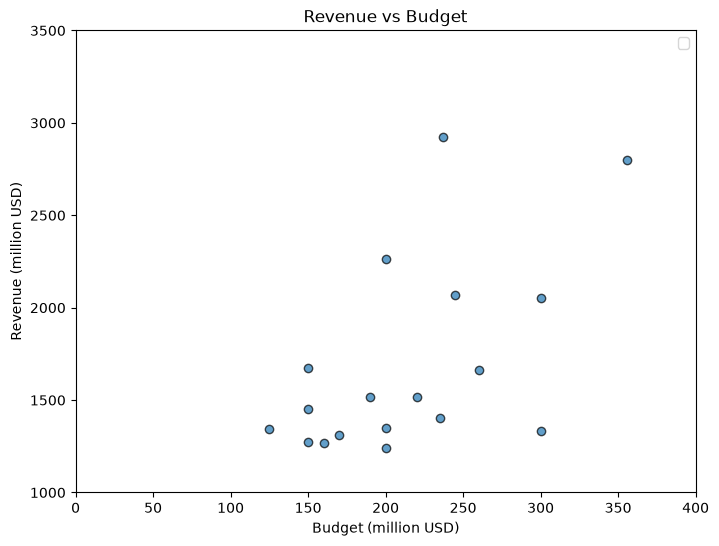

In [20]:
# 1) Revenue vs Budget (with break-even line)
visualization.revenue_vs_budget(df)
plt.show()

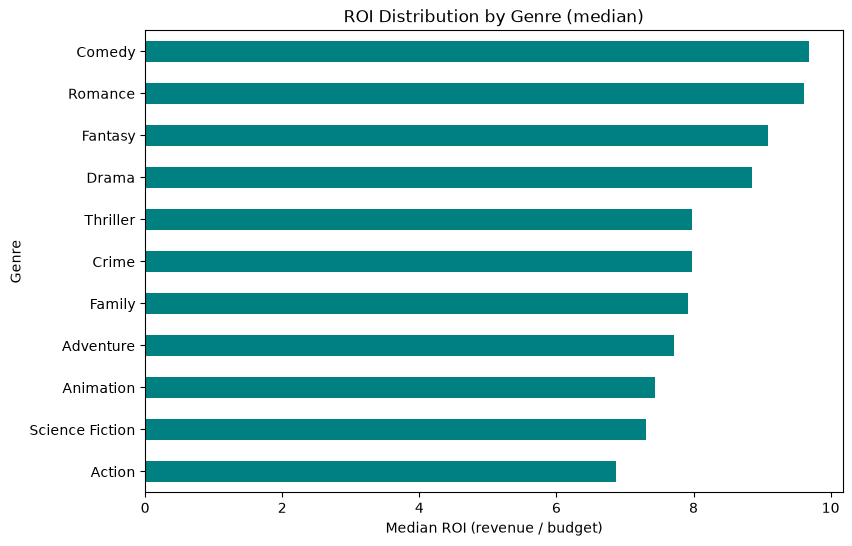

In [21]:
# 2) ROI distribution by genre
visualization.roi_by_genre(df)
plt.show()

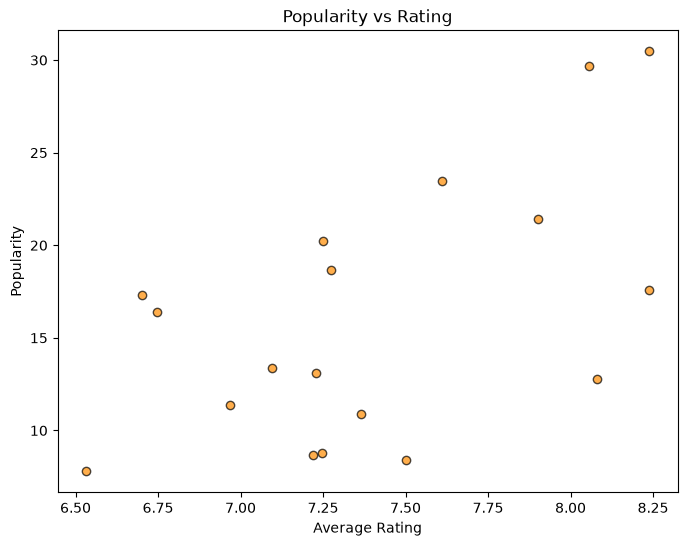

In [22]:
# 3) Popularity vs Rating
visualization.popularity_vs_rating(df)
plt.show()

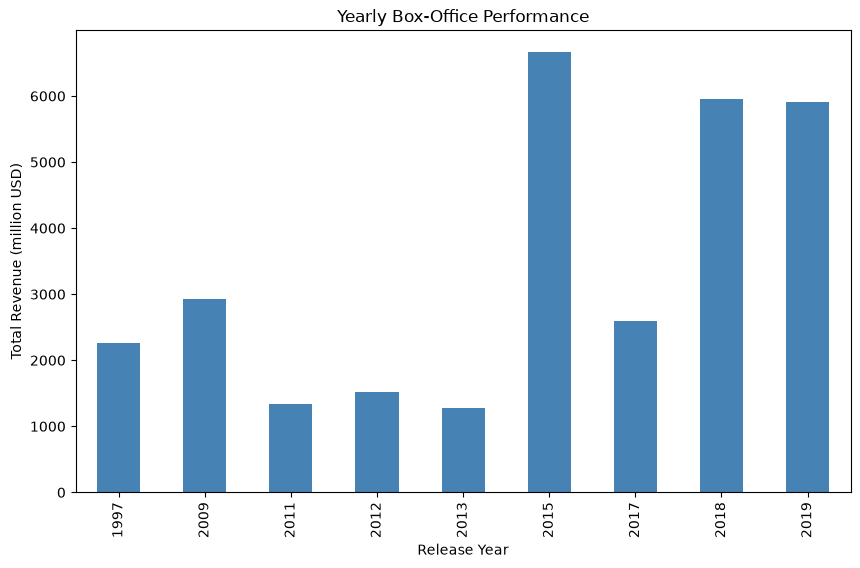

In [23]:
# 4) Yearly box-office performance
visualization.yearly_box_office(df)
plt.show()

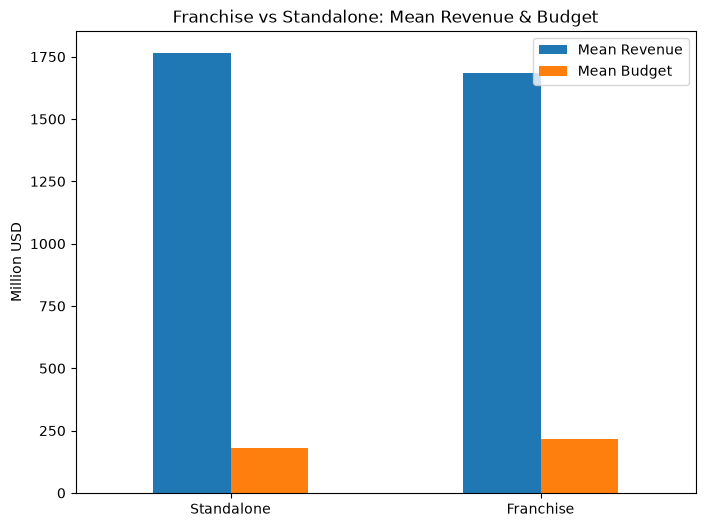

In [24]:
# 5) Franchise vs Standalone success
visualization.franchise_vs_standalone_plot(df)
plt.show()

### 5. Save the clean dataset

In [25]:
df.to_csv("movies_clean.csv", index=False)
print("Saved movies_clean.csv with", df.shape[0], "movies.")

Saved movies_clean.csv with 18 movies.
